In [1]:
import numpy as py 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import streamlit as st
import pickle
import numpy as np

In [2]:
df = pd.read_csv("insurance.csv")
df #dataframe

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

In [3]:
df.shape


(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.describe() #only numeric values ka description aayega 

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum() #we will check if we have null values or not, we will remove them in data cleaning

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

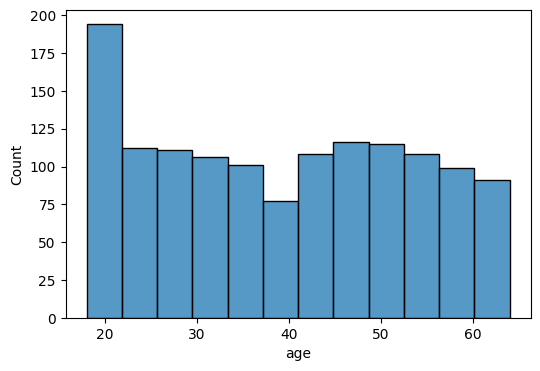

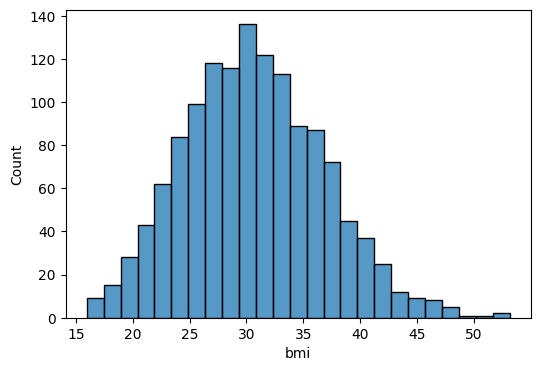

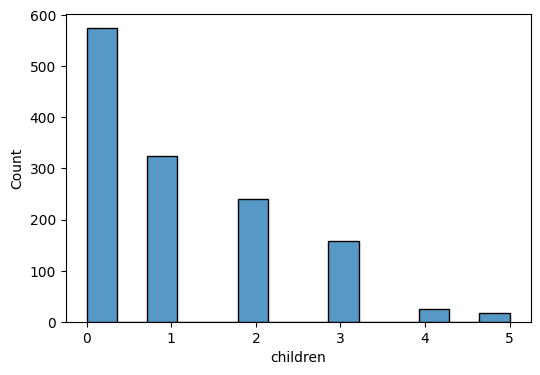

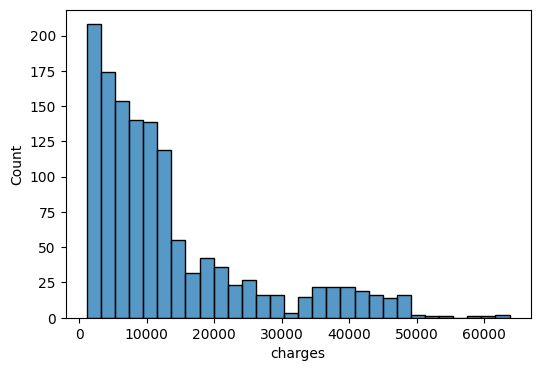

In [9]:
numeric_columns = ['age',  'bmi', 'children', 'charges'] #we will extract these columns 
#we will use loop now 
for col in numeric_columns:
    plt.figure(figsize=(6,4)) #itne pixels ka we will visualize our data 
    sns.histplot(df[col]) #we will create a histogram
# charges right skewed data hai 

<Axes: xlabel='children', ylabel='count'>

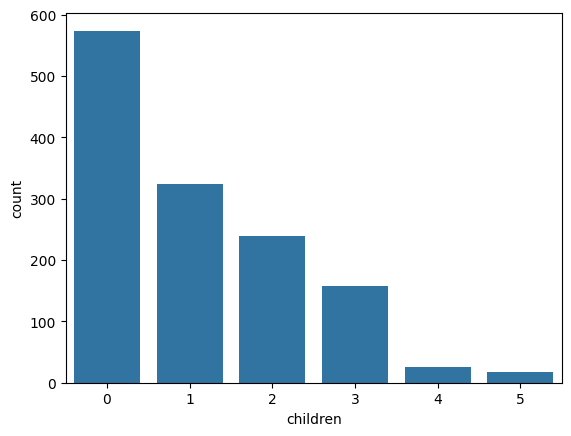

In [10]:
sns.countplot(x = df["children"])

<Axes: xlabel='sex', ylabel='count'>

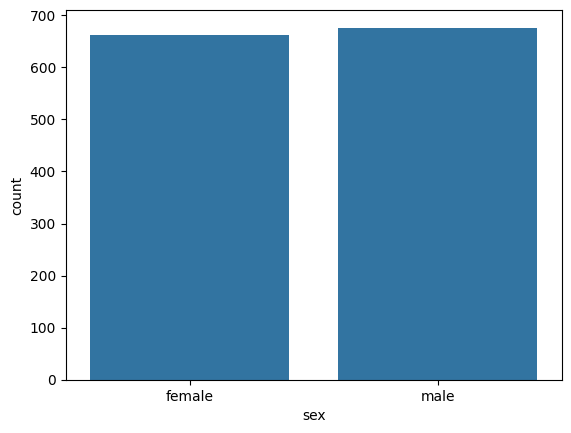

In [11]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

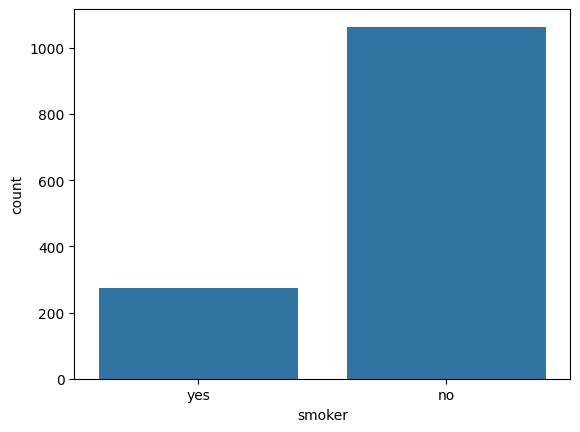

In [12]:
sns.countplot(x = df["smoker"])

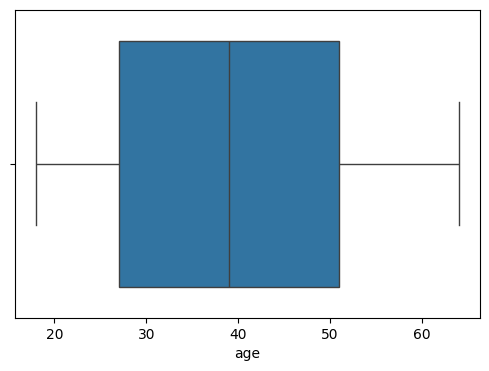

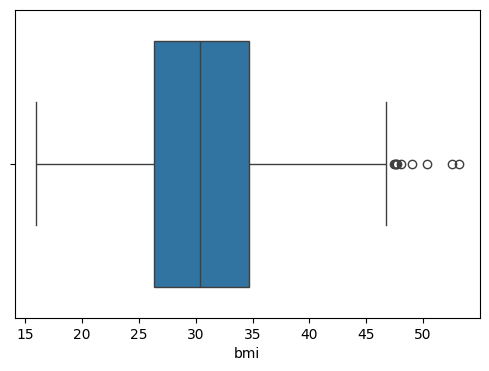

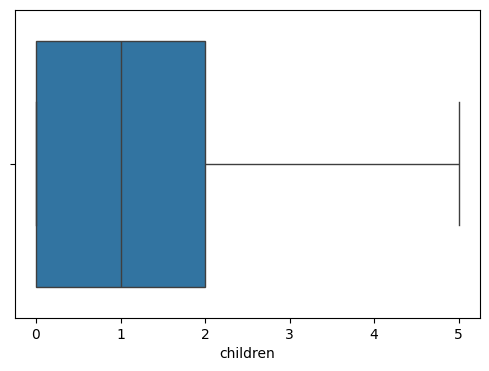

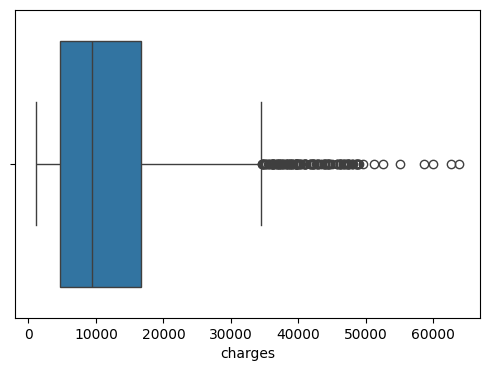

In [13]:
# now we will make boxplots 
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x= df[col])


<Axes: >

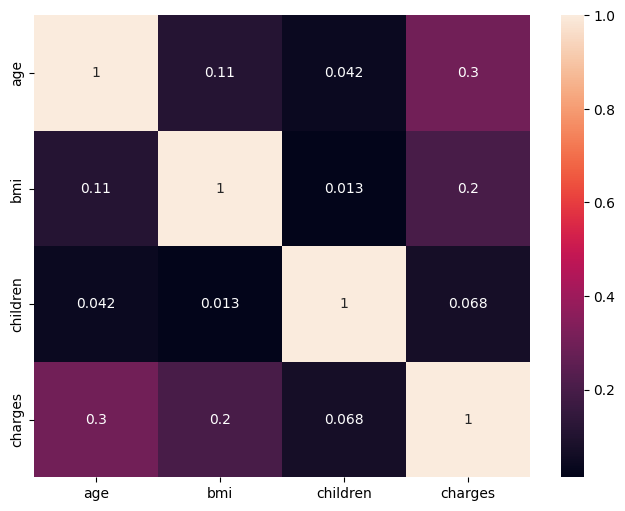

In [14]:
# ages mein koi outliers nahi haii 
#baki sbme hai 
# these are the steps for eda
# now we will se correlation and for doing it so we will make the correlation graph
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True), annot = True) # we will use heatmap and then send the correaltion data to heatmap  aur numeric values ka hi heatmap ban payega 

data cleaning and preprocessing

In [15]:
df_cleaned = df.copy() #maine ek naya variable banaya aur usme pura dataset copy kardiya 
df_cleaned.head()
df_cleaned.shape

(1338, 7)

In [16]:
df_cleaned.drop_duplicates(inplace=True) 

In [17]:
df_cleaned.shape


(1337, 7)

In [18]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [20]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [21]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male":0,"female":1}) #we have converted our data into numeric data 

In [22]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [23]:
df_cleaned['smoker'].value_counts(
)

smoker
no     1063
yes     274
Name: count, dtype: int64

In [24]:
df_cleaned['smoker']= df_cleaned['smoker'].map({"no":0 ,"yes":1})

In [25]:
df_cleaned.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [26]:
df_cleaned.rename(columns = {
    "sex":"isfemale",
    "smoker":"is_smoker"
}, inplace= True) #inplace se humari cheezein actual mein kaam kar jati hain

In [27]:
df_cleaned.head() #we used label encoding here 

,age,isfemale,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [28]:
df_cleaned["region"].value_counts() #we will use one hot encoding

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [29]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["region"],drop_first=True) #get dummies chahiye hume region column ke toh we inserted that in get dummies 
#we can write multiple columns too, we use drop first warna region will also get considered for the name of columns 

In [30]:
df_cleaned.head()

,age,isfemale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [31]:
df_cleaned= df_cleaned.astype(int)

In [32]:
df_cleaned

,age,isfemale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


#feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

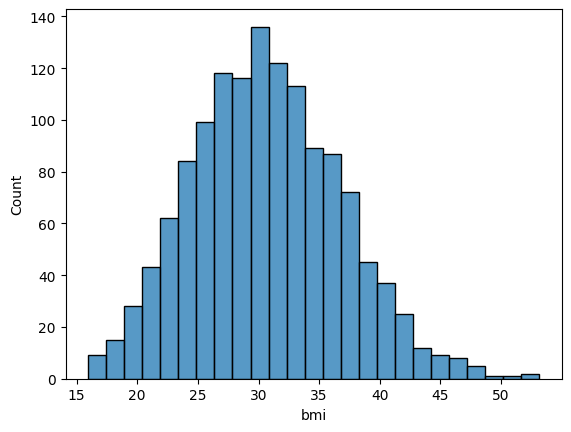

In [33]:
sns.histplot(df['bmi'])

In [34]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'], 
    bins=[0,18.5,24.9,29.9,float("inf")],
    labels=["underweight","normal","overweight","obese"]
) #cut option in pandas library 

In [35]:
df_cleaned

,age,isfemale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [36]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["bmi_category"],drop_first=True)


In [37]:
df_cleaned=df_cleaned.astype(int)

In [38]:
df_cleaned

,age,isfemale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [39]:
#now we will scale 
df_cleaned.columns

Index(['age', 'isfemale', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [40]:
from sklearn.preprocessing import StandardScaler
cols =["age","bmi","children"]  #there are the 3 columns jisme hum standard deviation lagakar same scale par le aaayenge 
scaler = StandardScaler()

df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [41]:
df_cleaned.head()

,age,isfemale,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [42]:
#hum charges ko nhi chhedenge kyunki its an output variable and hum output variable ko nhi chhedte 
#now we will do feature extraction
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation ki kiska correlation zyda hai jo ache se predict karne mein help karega about charges
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'isfemale', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}  #yahan ek dict ban jayegi 
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,isfemale,-0.058046
8,bmi_category_normal,-0.104042


In [43]:
# humara correlation humesha aayega +1 aur -1 ke bich mein, if my value is above o.5 or -0.5 then its highly correlated features so we will definately use them 
# we can conside 0.25 to 0.5, o.2 to 0.1 are negotiable if the accuracy is high when we use them then we use then if not then we dont use them. 

cat_features = [
    'isfemale', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
] #these are all categorical features and we will now use kqitosis where we compare category to category 

 

In [44]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isfemale,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [45]:
final_df = df_cleaned[['age', 'isfemale', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_obese']]
final_df

,age,isfemale,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


In [46]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [47]:
from sklearn.model_selection import train_test_split
X= final_df.drop("charges",axis = 1)
y= final_df["charges"]

In [48]:
 X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [49]:
#WE WILL USE LINEAR REGRESSION
from sklearn.linear_model import LinearRegression 

In [50]:
model= LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
# our model is created now we have to see how our model is working 
y_predict = model.predict(X_test)

In [52]:
#NOW WE WILL COMPARE BOTH ARE MODEL AND USE R2 TO DO SO 
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_predict)
r2

0.8040712413347116

In [53]:
# we are getting 80% similarity in our scores 
n = X_test.shape[0]
p= X_test.shape[1]
adjusted_r2= 1-((1-r2)*(n-1)/(n-p-1))

In [54]:
adjusted_r2

0.7987962362937231

In [55]:
# our model is performing good 80 % is good, we can deploy our model 
import os
os.listdir()

pickle.dump(model, open("model.pkl", "wb"))

scaler = StandardScaler().fit(X_train)
pickle.dump(scaler, open("scaler.pkl", "wb"))

columns = list(X_train.columns)
pickle.dump(columns, open("columns.pkl", "wb"))


In [56]:
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))


In [57]:
type(scaler)


sklearn.preprocessing._data.StandardScaler

In [58]:
getattr(scaler, "n_features_in_", "NA")


7

In [59]:
columns


['age',
 'isfemale',
 'bmi',
 'children',
 'is_smoker',
 'region_southeast',
 'bmi_category_obese']

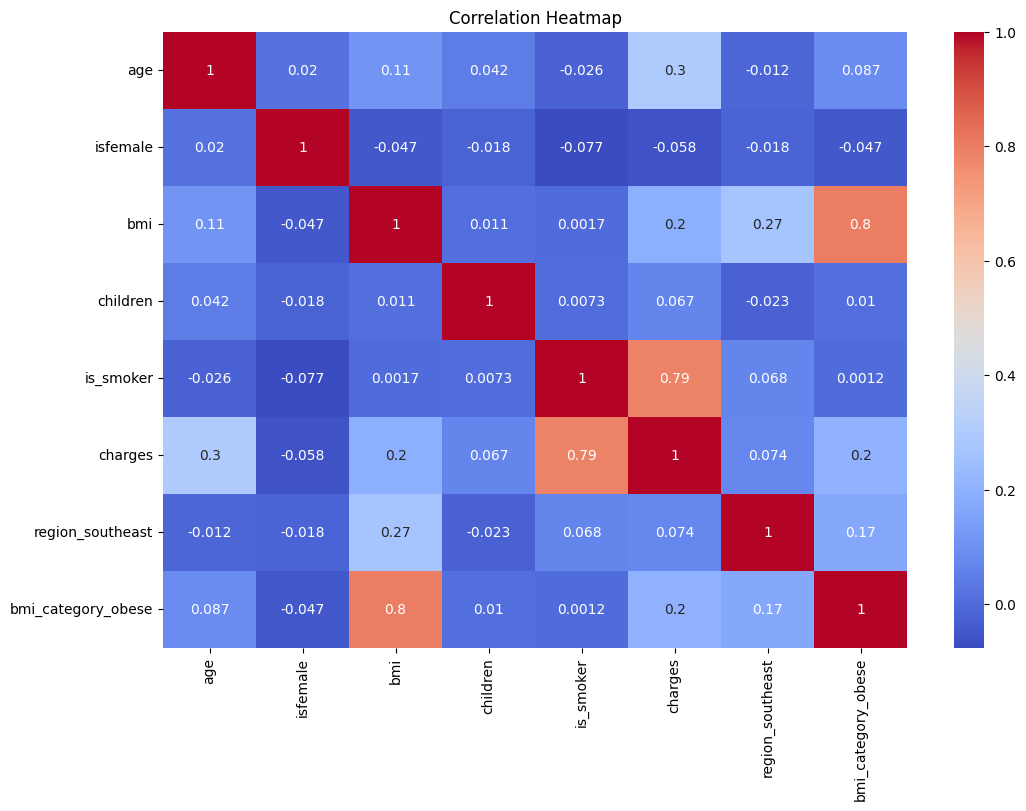

In [60]:
plt.figure(figsize=(12,8))
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


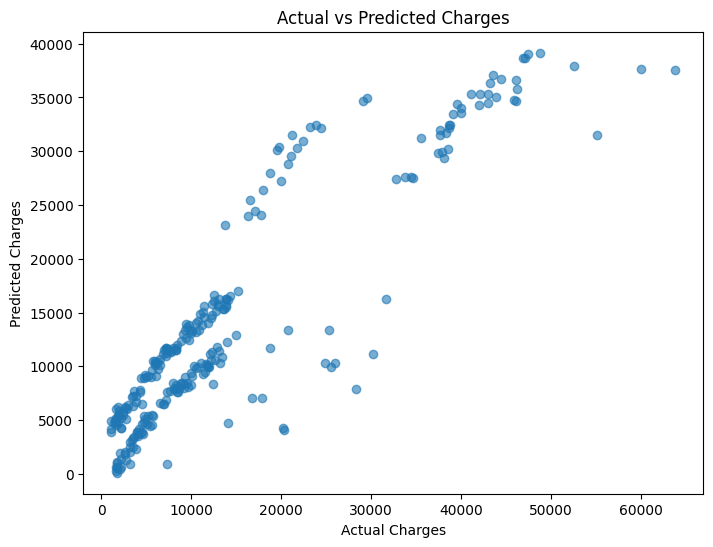

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_predict, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()


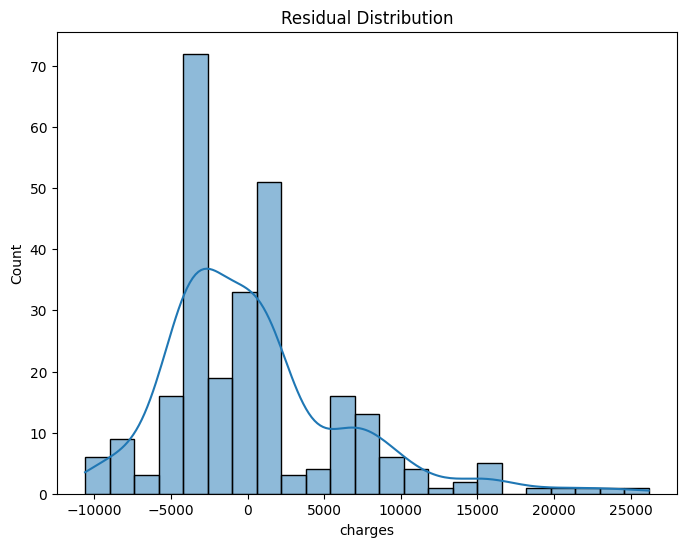

In [62]:
residuals = y_test - y_predict

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

# RAE Calculation
rae = np.sum(np.abs(y_test - y_predict)) / np.sum(np.abs(y_test - np.mean(y_test)))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)
print("RAE :", rae)


MAE : 4295.197838389796
MSE : 36003101.65243355
RMSE : 6000.258465469096
R2 Score : 0.8040712413347116
RAE : 0.415335475936636


In [64]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score", "RAE"],
    "Value": [mae, mse, rmse, r2, rae]
})

metrics_df


,Metric,Value
0,MAE,4.295198e+03
1,MSE,3.600310e+07
2,RMSE,6.000258e+03
3,R2 Score,8.040712e-01
4,RAE,4.153355e-01


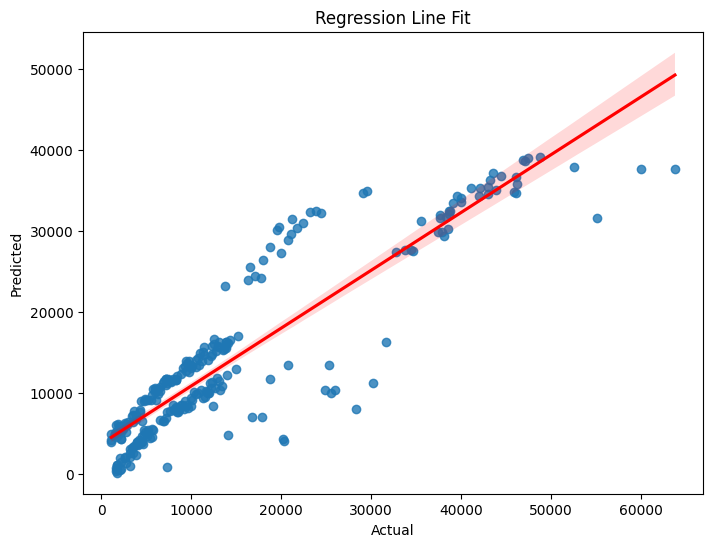

In [65]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_predict, line_kws={"color":"red"})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Regression Line Fit")
plt.show()
